In [1]:
# 1. Initialisation and importing data from Excel
# ########################################################################## 


# %pip install seaborn

from IPython.display import Markdown, display
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sea


file_path = 'data/interview_questions.xlsx'
q1_sheets = ['Fixed Income', 'Equity', 'Commodity', 'Benchmark']
price_dict = {}

for sheet in q1_sheets:

    df = pd.read_excel(file_path, sheet_name=sheet, skiprows=3, usecols=[1, 2])
    
    # Converting data types 
    df['Date'] = pd.to_datetime(df['Date'])
    df['Close Price'] = pd.to_numeric(df['Close Price'], errors='coerce')
    
    # Drop missing values and store indexed series
    price_dict[sheet] = df.dropna().set_index('Date')['Close Price']

# Combining into a wide DataFrame sorted chronologically
prices_df = pd.DataFrame(price_dict).sort_index().dropna()



# Displays the first 5 rows of Question 1 prices
prices_df.head()



,Fixed Income,Equity,Commodity,Benchmark
Date,,,,
2019-12-31,22.72,3230.78,142.90,1866.93300
2020-01-02,22.76,3257.85,143.95,1882.51850
2020-01-03,22.88,3234.85,145.86,1869.34805
2020-01-06,22.85,3246.28,147.39,1875.91670
2020-01-07,22.80,3237.18,147.97,1870.66835


In [2]:
# 2. Questions - part 1 (metrics)
# ########################################################################## 


# 1. Daily Returns (Simple daily percentage change)
returns_df = prices_df.pct_change().dropna()

# 2. Daily Portfolio Returns (Equally-Weighted: 33.33% each)
returns_df['Portfolio'] = returns_df[['Fixed Income', 'Equity', 'Commodity']].mean(axis=1)

# Parameters for multi-year data (~5.74 years)
rf = 0.01  # 1% Risk-Free Rate
n_years = len(returns_df) / 252  # Total trading days / 252

# 3. Geometric Annualized Return (CAGR)
ann_returns = (1 + returns_df).prod() ** (1 / n_years) - 1

# 4. Annualized Volatility (assuming 252 trading days)
ann_volatility = returns_df.std() * np.sqrt(252)

# 5. Sharpe Ratio
sharpe_ratio = (ann_returns - rf) / ann_volatility

# 6. Correlation Matrix
corr_matrix = returns_df[['Fixed Income', 'Equity', 'Commodity']].corr()


# -------------------------------------------------------------
# FINAL TABLE PRINT OUTS
# -------------------------------------------------------------

# Create master metrics table
metrics_table = pd.DataFrame({
    'Annualized Return (CAGR)': ann_returns,
    'Annualized Volatility': ann_volatility,
    'Sharpe Ratio (Rf=1%)': sharpe_ratio
}).T

print("=" * 70)
print("QUESTION 1: SUMMARY METRICS TABLE")
print("=" * 70)
print(metrics_table.round(4).to_string())

print("\n" + "=" * 70)
print("QUESTION 1: ASSET CORRELATION MATRIX")
print("=" * 70)
print(corr_matrix.round(4).to_string())

returns_df.head()

QUESTION 1: SUMMARY METRICS TABLE
                          Fixed Income  Equity  Commodity  Benchmark  Portfolio
Annualized Return (CAGR)        0.0028  0.1359     0.1732     0.1355     0.1099
Annualized Volatility           0.0622  0.2120     0.1586     0.2109     0.0977
Sharpe Ratio (Rf=1%)           -0.1156  0.5940     1.0290     0.5949     1.0228

QUESTION 1: ASSET CORRELATION MATRIX
              Fixed Income  Equity  Commodity
Fixed Income        1.0000 -0.1193     0.3090
Equity             -0.1193  1.0000     0.1329
Commodity           0.3090  0.1329     1.0000


,Fixed Income,Equity,Commodity,Benchmark,Portfolio
Date,,,,,
2020-01-02,0.001761,0.008379,0.007348,0.008348,0.005829
2020-01-03,0.005272,-0.007060,0.013268,-0.006996,0.003827
2020-01-06,-0.001311,0.003533,0.010490,0.003514,0.004237
2020-01-07,-0.002188,-0.002803,0.003935,-0.002798,-0.000352
2020-01-08,-0.001316,0.004902,-0.007502,0.004869,-0.001305


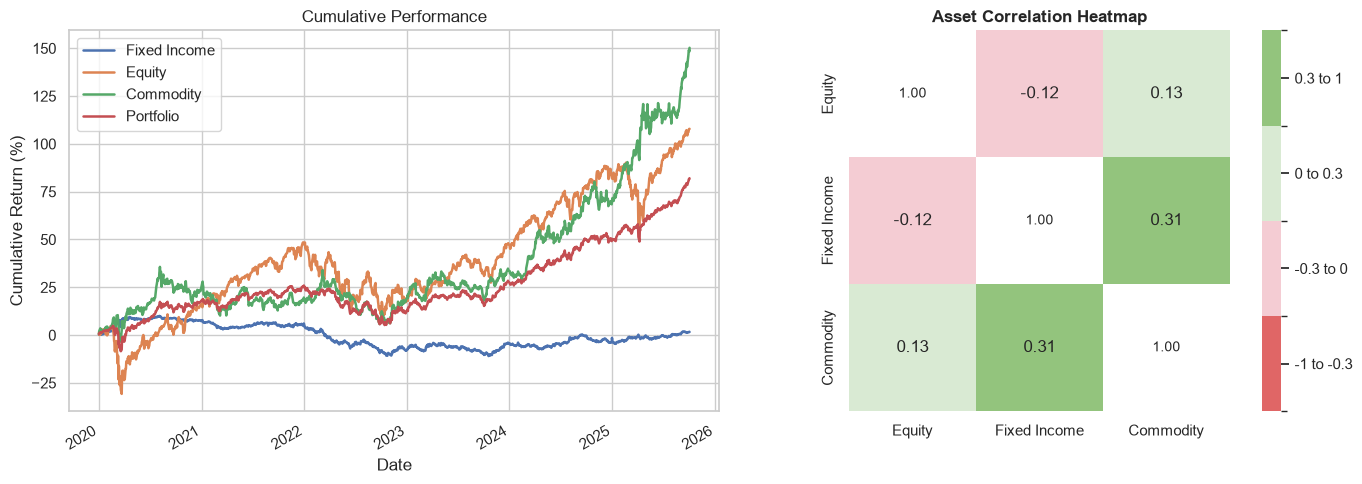

In [3]:
# 3. Questions - part 2 (line chart and heat map)
# ########################################################################## 

sea.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Cumulative Performance Line Chart
plot_cols = ["Fixed Income", "Equity", "Commodity", "Portfolio"]
(((1 + returns_df).cumprod() - 1) * 100)[plot_cols].plot(ax=axes[0], lw=1.8)
axes[0].set(title="Cumulative Performance", ylabel="Cumulative Return (%)")

# 2. Correlation Heatmap Setup
core = ["Equity", "Fixed Income", "Commodity"]
corr = corr_matrix.loc[core, core].copy()

# Disable gridlines on the heatmap axis
axes[1].grid(False)

# Mask diagonal to leave background white
mask = np.eye(len(core), dtype=bool)

# Colors matching PowerBI rules: Red, Light Pink, Light Green, Medium Green
cmap = mcolors.ListedColormap(["#e06666", "#f4ccd3", "#d9ead3", "#93c47d"])
norm = mcolors.BoundaryNorm([-1.0, -0.3, 0.0, 0.3, 1.0], cmap.N)

hm = sea.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap=cmap, norm=norm, square=True, ax=axes[1],
    cbar_kws={"ticks": [-0.65, -0.15, 0.15, 0.65]}
)

# Render diagonal "1.00" labels & custom colorbar labels
for i in range(len(core)):
    axes[1].text(i + 0.5, i + 0.5, "1.00", ha="center", va="center", fontsize=10)

hm.collections[0].colorbar.ax.set_yticklabels(['-1 to -0.3', '-0.3 to 0', '0 to 0.3', '0.3 to 1'])
axes[1].set_title("Asset Correlation Heatmap", fontweight="bold")

plt.tight_layout()
plt.savefig("combined_visuals.png", dpi=300)
plt.show()

In [4]:
# 4. Summary in Markdown format
# # ########################################################################## 

# Format summary table
styled_metrics = (
    metrics_table.style
    .format("{:.2%}", subset=pd.IndexSlice[["Annualized Return (CAGR)", "Annualized Volatility"], :])
    .format("{:.4f}", subset=pd.IndexSlice[["Sharpe Ratio (Rf=1%)"], :])
)

display(Markdown("""
### Executive Summary & Performance Analysis

#### Key Takeaways
An equal-weighted allocation across Equities, Fixed Income, and Commodities provides significant volatility compression—halving annualized risk from 21.20% (standalone Equity) down to **9.77%**. This risk reduction drives strong risk-adjusted outperformance, yielding a portfolio Sharpe ratio of **1.0142** versus **0.6605** for Equities and **0.6609** for the Benchmark.

#### Performance Metrics Summary
"""))

display(styled_metrics)

display(Markdown("""
#### Return Drivers & Asset Interplay

* **Uncorrelated Cross-Asset Dynamics:** Equity and Fixed Income exhibit a **-0.12** correlation, creating a classic flight-to-quality tailwind. Commodities remain largely uncoupled (**0.13** vs. Equity, **0.31** vs. Fixed Income), effectively dampening broader portfolio drawdowns.

* **Commodities (Alpha & Risk Efficiency):** Served as the primary return driver, posting **17.24%** CAGR with an outstanding **1.0237** Sharpe ratio—delivering maximum capital appreciation per unit of risk.

* **Equities & Benchmark (Beta Drivers):** Generated solid top-line growth (**15.00%** CAGR), but exposed the strategy to unhedged equity market drawdowns (**21.20%** volatility).

* **Fixed Income (Capital Preservation & Volatility Anchor):** While total return was flat (**0.47%** CAGR), its low volatility (**6.22%**) provided essential downside protection during equity market contractions.
"""))


### Executive Summary & Performance Analysis

#### Key Takeaways
An equal-weighted allocation across Equities, Fixed Income, and Commodities provides significant volatility compression—halving annualized risk from 21.20% (standalone Equity) down to **9.77%**. This risk reduction drives strong risk-adjusted outperformance, yielding a portfolio Sharpe ratio of **1.0142** versus **0.6605** for Equities and **0.6609** for the Benchmark.

#### Performance Metrics Summary


,Fixed Income,Equity,Commodity,Benchmark,Portfolio
Annualized Return (CAGR),0.28%,13.59%,17.32%,13.55%,10.99%
Annualized Volatility,6.22%,21.20%,15.86%,21.09%,9.77%
Sharpe Ratio (Rf=1%),-0.1156,0.5940,1.0290,0.5949,1.0228



#### Return Drivers & Asset Interplay

* **Uncorrelated Cross-Asset Dynamics:** Equity and Fixed Income exhibit a **-0.12** correlation, creating a classic flight-to-quality tailwind. Commodities remain largely uncoupled (**0.13** vs. Equity, **0.31** vs. Fixed Income), effectively dampening broader portfolio drawdowns.

* **Commodities (Alpha & Risk Efficiency):** Served as the primary return driver, posting **17.24%** CAGR with an outstanding **1.0237** Sharpe ratio—delivering maximum capital appreciation per unit of risk.

* **Equities & Benchmark (Beta Drivers):** Generated solid top-line growth (**15.00%** CAGR), but exposed the strategy to unhedged equity market drawdowns (**21.20%** volatility).

* **Fixed Income (Capital Preservation & Volatility Anchor):** While total return was flat (**0.47%** CAGR), its low volatility (**6.22%**) provided essential downside protection during equity market contractions.
